In [120]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [121]:
observations = 1000
xs = np.random.uniform(low=-10, high=10, size=(observations, 1))
zs = np.random.uniform(low=-10,high=10, size=(observations, 1))
inputs = np.column_stack((xs, zs))
print(inputs.shape)

(1000, 2)


In [122]:
noise = np.random.uniform(low=-1,high=1, size=(observations, 1))
targets = 13*xs + 7*zs -12 + noise
np.savez('TF_dataset', inputs=inputs, targets=targets)
print(targets.shape)

(1000, 1)


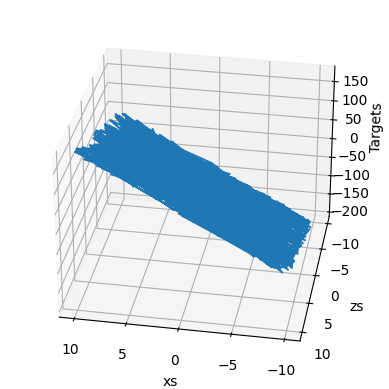

In [123]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [124]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2, 1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights,biases)

[[0.04993196]
 [0.04966966]] [0.0278236]


In [125]:
targets = targets.reshape(observations,1)
eta = 0.02
for i in range(100):
  outputs = np.dot(inputs, weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas ** 2) / 2 / observations
  print(loss)

  deltas_scaled = deltas / observations
  weights = weights - eta * np.dot(inputs.T, deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)

3851.5004543653904
423.85618425961485
101.46712624213748
67.132165581846
61.28337724166326
58.50937718506386
56.16011418892714
53.940263204028994
51.8125824852128
49.769592983835246
47.80747648146079
45.92297606228497
44.113014482700706
42.37464258286253
40.705028654335855
39.10145309313175
37.56130387686617
36.082072298312674
34.66134887753915
33.296819436980705
31.986261331915056
30.727539830053974
29.518604634335905
28.35748654325303
27.242294243272816
26.17121122812887
25.142492839963776
24.154463427503288
23.20551361663406
22.294097688937924
21.41873106391343
20.577987880783265
19.77049867594863
18.994948152307312
18.25007303680215
17.534660022710252
16.847543793320607
16.187605123781704
15.553769058026653
14.945003157806616
14.360315820980471
13.798754666321024
13.259404982207313
12.74138823667592
12.24386064640414
11.766011802294422
11.307063349421197
10.866267719189695
10.442906911641963
10.036291325926372
9.64575863702554
9.270672716913303
8.910422598383093
8.564421479860185
8

In [126]:
print(weights, biases)

[[13.01124128]
 [ 7.00069001]] [-10.4144555]


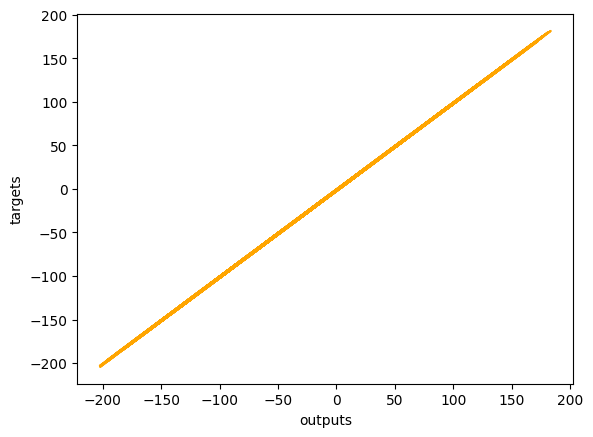

In [127]:
plt.plot(outputs,targets,color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()